In [1]:
from experiments.dj.likelihood_tables import LikelihoodConfig
from experiments.dj.result_tables import (
    AdaptPriorResult,
    FlowPriorResult,
    LikelihoodResult,
)
from experiments.dj.prior_tables import FlowPriorConfig
from experiments.dj.trainer_tables import FPTrainerConfig, LLTrainerConfig
from experiments.dj.dataloader_tables import DataLoaderConfig
from experiments.dj.dj_helpers import fetch_best_model_results
import gensn.distributions as G
import torch
from task_transfer.ml_lib.data_loading import build_dataloaders
from task_transfer.evaluation.evaluate_generative_model import (
    evaluate_flow_prior,
    compute_logl,
    adapt_prior_eval_criterion,
    compute_joint_logl,
    logl_mc_marginal_eval,
)


from experiments.dj.posterior_tables import SBVGPConfig

from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import (
    SBVGPResult,
    SIResult,
    FlowPriorResult,
    AdaptPriorResult,
)
from experiments.dj.dataloader_tables import DataLoaderConfig

from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import compute_logl
from task_transfer.evaluation.evaluate_generative_model import (
    compute_logl_marginal,
    compute_logl_data_marginal,
)
import torch
import matplotlib.pyplot as plt
import seaborn as sns


import numpy as np
from task_transfer.utils.math_utils import cos2_von_mises

from task_transfer.utils.model_utils import build_haefner_model

torch.manual_seed(42)

import experiments.orientation_discrimination.haefner_model.configs as cfg

[2024-07-17 14:40:47,456][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-07-17 14:40:48,700][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
import wandb

wandb.init(project="random", entity="walkerlab")

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: sshr (walkerlab). Use `wandb login --relogin` to force relogin


In [3]:
restrictions = (
    "orig_dl_id = 'b8379e7d6998fc94a08a9a3742eec12d' "
    "and dl_id = 'b8379e7d6998fc94a08a9a3742eec12d' "
    "and trainer_id = 'a7e83afb3d10e49d76cbfbe16c294932'"
)

AdaptPriorResult & restrictions

seed,prior_fp_id to index into FlowPriorConfig,prior_trainer_id to index into FPTrainerConfig,likelihood_id to index into LikelihoodConfig,likelihood_trainer_id to index into LLTrainerConfig,orig_dl_id to index into DataLoaderConfig used for the prior and likelihood training,trainer_id,dl_id,"train_marginal_obs_ll_mean mean per trial, per sample, in nats",train_marginal_obs_ll_sem standard error of the mean,val_marginal_obs_ll_mean,val_marginal_obs_ll_sem,test_marginal_obs_ll_mean,test_marginal_obs_ll_sem,"train_prior_ll_mean mean per trial, per sample, in nats",train_prior_ll_sem standard error of the mean,val_prior_ll_mean,val_prior_ll_sem,test_prior_ll_mean,test_prior_ll_sem,tracker_output,eval_output,model trained joint model NOT just the prior
-100,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,b8379e7d6998fc94a08a9a3742eec12d,a7e83afb3d10e49d76cbfbe16c294932,b8379e7d6998fc94a08a9a3742eec12d,-3093.501953125,263.9532775878906,-3153.096435546875,521.27001953125,-3096.017822265625,664.123779296875,-270.6148681640625,4.0057291984558105,-271.60150146484375,7.666747570037842,-270.1019592285156,10.834356307983398,=BLOB=,=BLOB=,=BLOB=
-42,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,b8379e7d6998fc94a08a9a3742eec12d,a7e83afb3d10e49d76cbfbe16c294932,b8379e7d6998fc94a08a9a3742eec12d,-3062.269775390625,256.8599853515625,-3152.7138671875,534.7520751953125,-3036.32568359375,656.5575561523438,-292.42999267578125,4.401054859161377,-293.0040588378906,8.161787986755371,-290.9249572753906,11.700278282165527,=BLOB=,=BLOB=,=BLOB=
42,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,b8379e7d6998fc94a08a9a3742eec12d,a7e83afb3d10e49d76cbfbe16c294932,b8379e7d6998fc94a08a9a3742eec12d,-2995.144287109375,260.65789794921875,-3027.970703125,524.765625,-2948.1591796875,653.7885131835938,-93.53241729736328,1.7952336072921753,-93.68653869628906,3.3797712326049805,-93.8666763305664,4.615384578704834,=BLOB=,=BLOB=,=BLOB=
100,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,b8379e7d6998fc94a08a9a3742eec12d,a7e83afb3d10e49d76cbfbe16c294932,b8379e7d6998fc94a08a9a3742eec12d,-2954.5322265625,241.97532653808594,-3034.613037109375,513.7304077148438,-2931.286865234375,622.6848754882812,-174.08172607421875,2.2538671493530273,-173.86398315429688,4.246375560760498,-174.03640747070312,5.926455974578857,=BLOB=,=BLOB=,=BLOB=


In [4]:
adapted_prior = (AdaptPriorResult & restrictions).fetch(
    download_path="/tmp",
    order_by="val_marginal_obs_ll_mean DESC",
    limit=1,
    as_dict=True,
)[0]

In [5]:
adapted_prior_model = torch.load(adapted_prior["model"], map_location="cpu")

In [ ]:

adapted_prior_exp = (AdaptPriorResult & restrictions).fetch(
    download_path="/tmp",
    order_by="val_marginal_obs_ll_mean DESC",
    limit=1,
    as_dict=True,
)[0]

In [12]:
download_path = "/tmp"
criterion = "val_ll_mean"
k = 1

trained_prior_restriction = (
    f"dl_id = 'b8379e7d6998fc94a08a9a3742eec12d'"
)
prior_result_table = FlowPriorResult & trained_prior_restriction

dataloader_restrictions = (
    f"data_fname = '/src/project/data/synthetic/haefner_2afc/flat_haefner_dataset.pkl'"
)
dataloader_table = DataLoaderConfig & dataloader_restrictions

prior_config_proj_col = "fp_id"
best_val_prior_results = fetch_best_model_results(
    result_table=prior_result_table,
    config_table=FlowPriorConfig,
    data_loader_config_table=dataloader_table,
    trainer_config_table=FPTrainerConfig,
    config_proj_col=prior_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
prior_model = torch.load(best_val_prior_results["model"], map_location="cpu")

# get likelihood model for marginal likelihood
likelihood_config_proj_col = "ll_id"
likelihood_restrictions = restriction = "dl_id = 'b8379e7d6998fc94a08a9a3742eec12d'"
likelihood_result_table = LikelihoodResult & likelihood_restrictions

best_val_likelihood_results = fetch_best_model_results(
    result_table=likelihood_result_table,
    config_table=LikelihoodConfig,
    data_loader_config_table=dataloader_table,
    trainer_config_table=LLTrainerConfig,
    config_proj_col=likelihood_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
likelihood_model = torch.load(best_val_likelihood_results["model"], map_location="cpu")

dataloader_args = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/flat_haefner_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
}
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=dataloader_args["data_fname"],
    train_prop=dataloader_args["train_prop"],
    val_prop=dataloader_args["val_prop"],
    batch_size=128,
)

joint_model = G.Joint(prior=prior_model, conditional=likelihood_model)

In [13]:
true_prior = G.IndependentExponential(rate=torch.ones(45))

In [14]:
data_dim = 1
cond_dim = 0
mc_sample_size = 10_000
device = "cpu"
reduction = "none"
uncertainty = "sem"
normalize = "none"
unit = "nats"
true_logl_marg_train, _ = compute_logl_marginal(
    conditional=likelihood_model,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_logl_marg_val, _ = compute_logl_marginal(
    conditional=likelihood_model,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_logl_marg_test, _ = compute_logl_marginal(
    conditional=likelihood_model,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [15]:
true_data_logl_marg_train, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=train_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_data_logl_marg_val, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=val_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_data_logl_marg_test, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=test_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [16]:
logl_mc_marg_task_train, _ = logl_mc_marginal_eval(
    joint_model=joint_model,
    data_loader=train_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_task_val, _ = logl_mc_marginal_eval(
    joint_model=joint_model,
    data_loader=val_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_task_test, _ = logl_mc_marginal_eval(
    joint_model=joint_model,
    data_loader=test_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [17]:
logl_mc_marg_adpt_train, _ = logl_mc_marginal_eval(
    joint_model=adapted_prior_model,
    data_loader=train_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_adpt_val, _ = logl_mc_marginal_eval(
    joint_model=adapted_prior_model,
    data_loader=val_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_adpt_test, _ = logl_mc_marginal_eval(
    joint_model=adapted_prior_model,
    data_loader=test_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

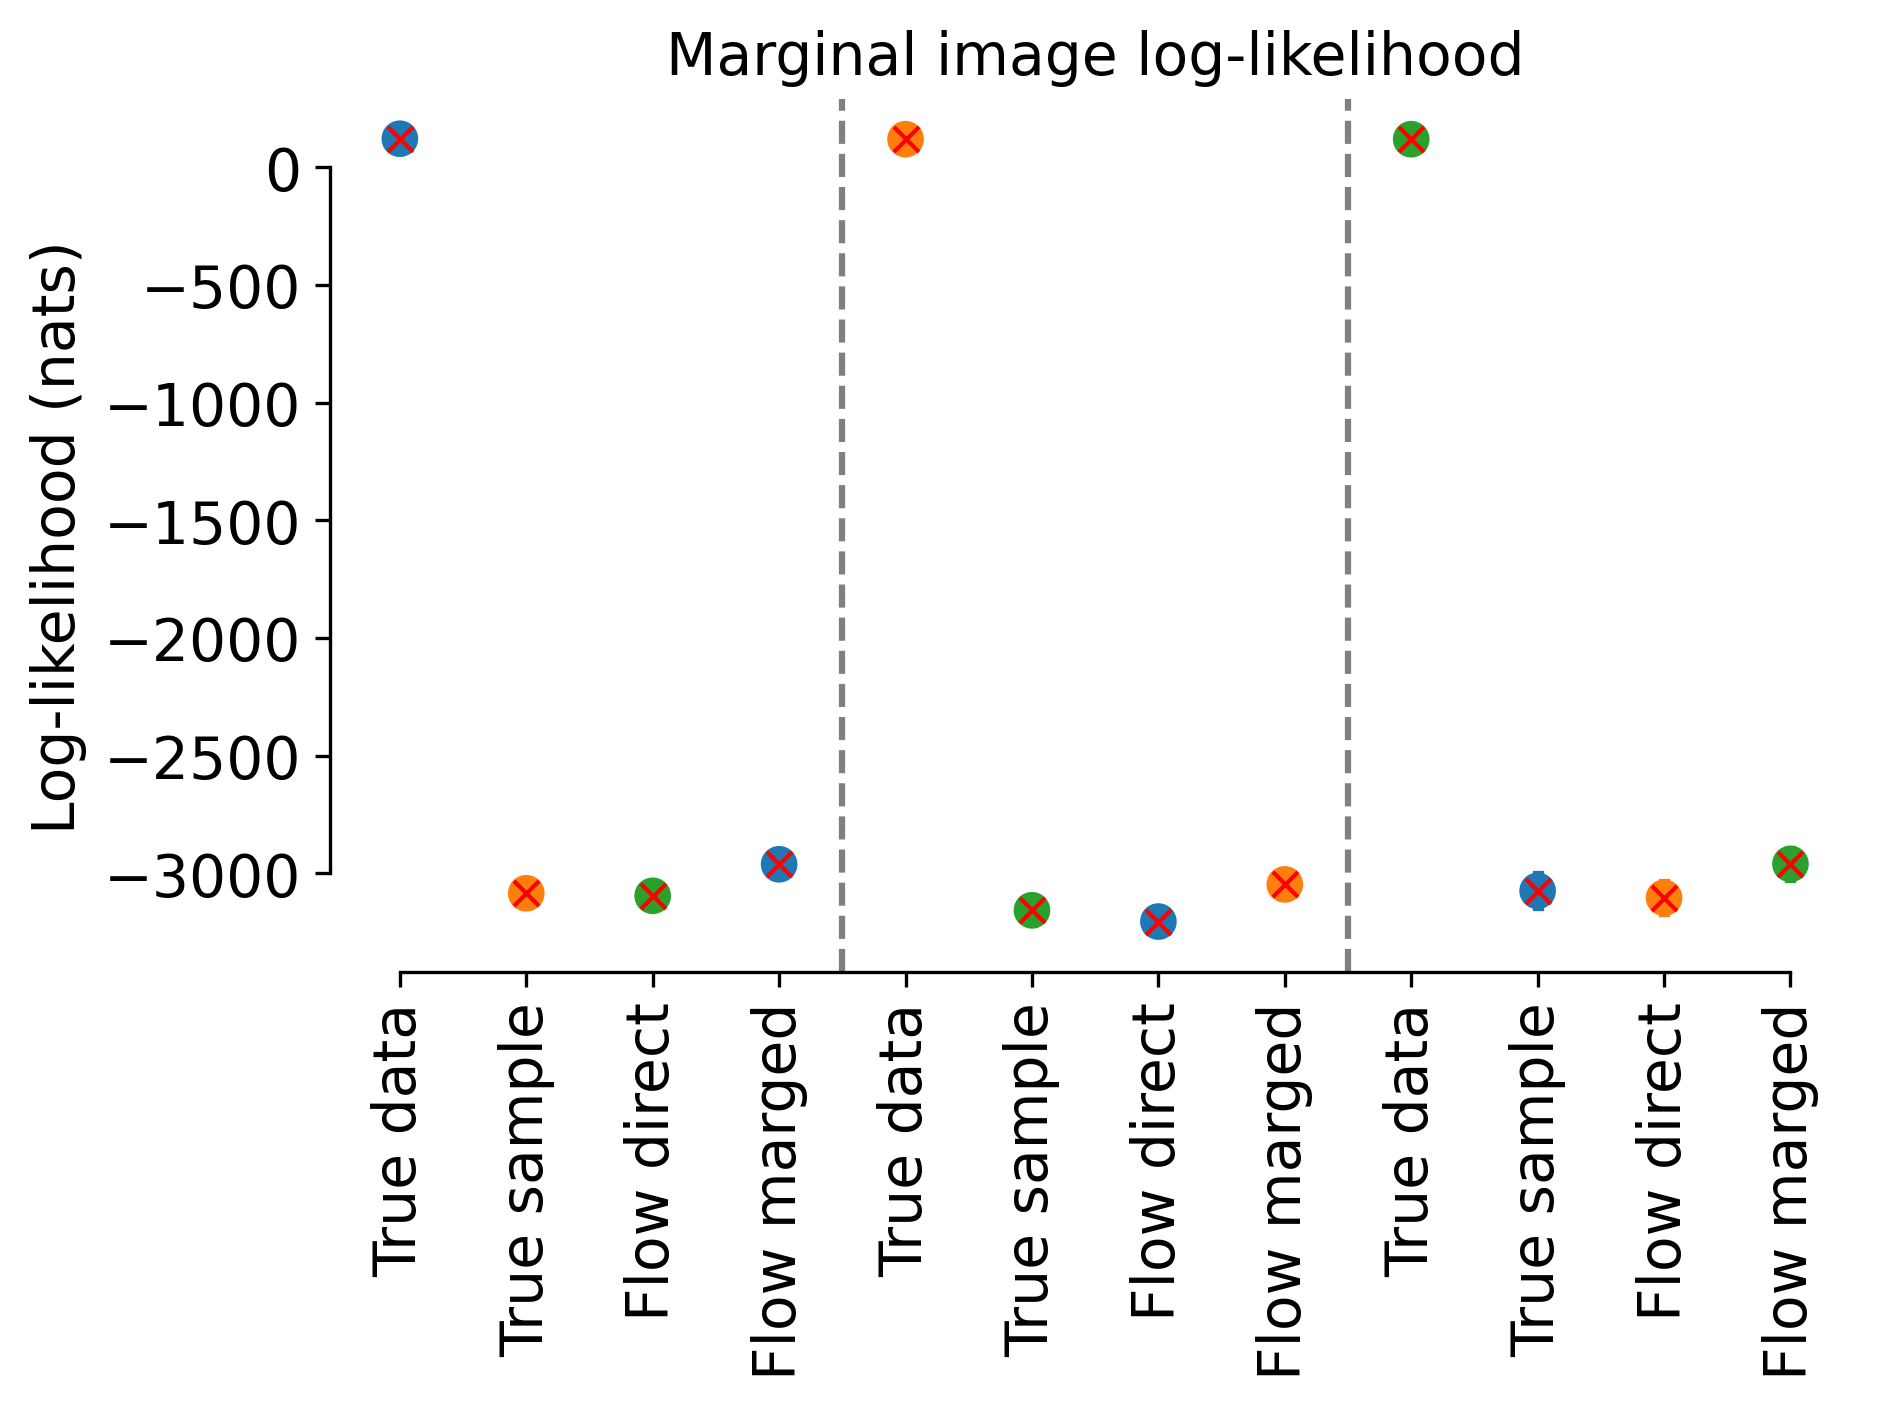

In [18]:
data = [
    true_data_logl_marg_train.detach(),
    true_logl_marg_train.detach(),
    logl_mc_marg_task_train.detach(),
    logl_mc_marg_adpt_train.detach(),
    true_data_logl_marg_val.detach(),
    true_logl_marg_val.detach(),
    logl_mc_marg_task_val.detach(),
    logl_mc_marg_adpt_val.detach(),
    true_data_logl_marg_test.detach(),
    true_logl_marg_test.detach(),
    logl_mc_marg_task_test.detach(),
    logl_mc_marg_adpt_test.detach(),
]
labels = [
    "True data",
    "True sample",
    "Flow direct",
    "Flow marged",
    "True data",
    "True sample",
    "Flow direct",
    "Flow marged",
    "True data",
    "True sample",
    "Flow direct",
    "Flow marged",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=3)
ax = sns.pointplot(data=data, ax=ax, palette=palette, errorbar="se")
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 4 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

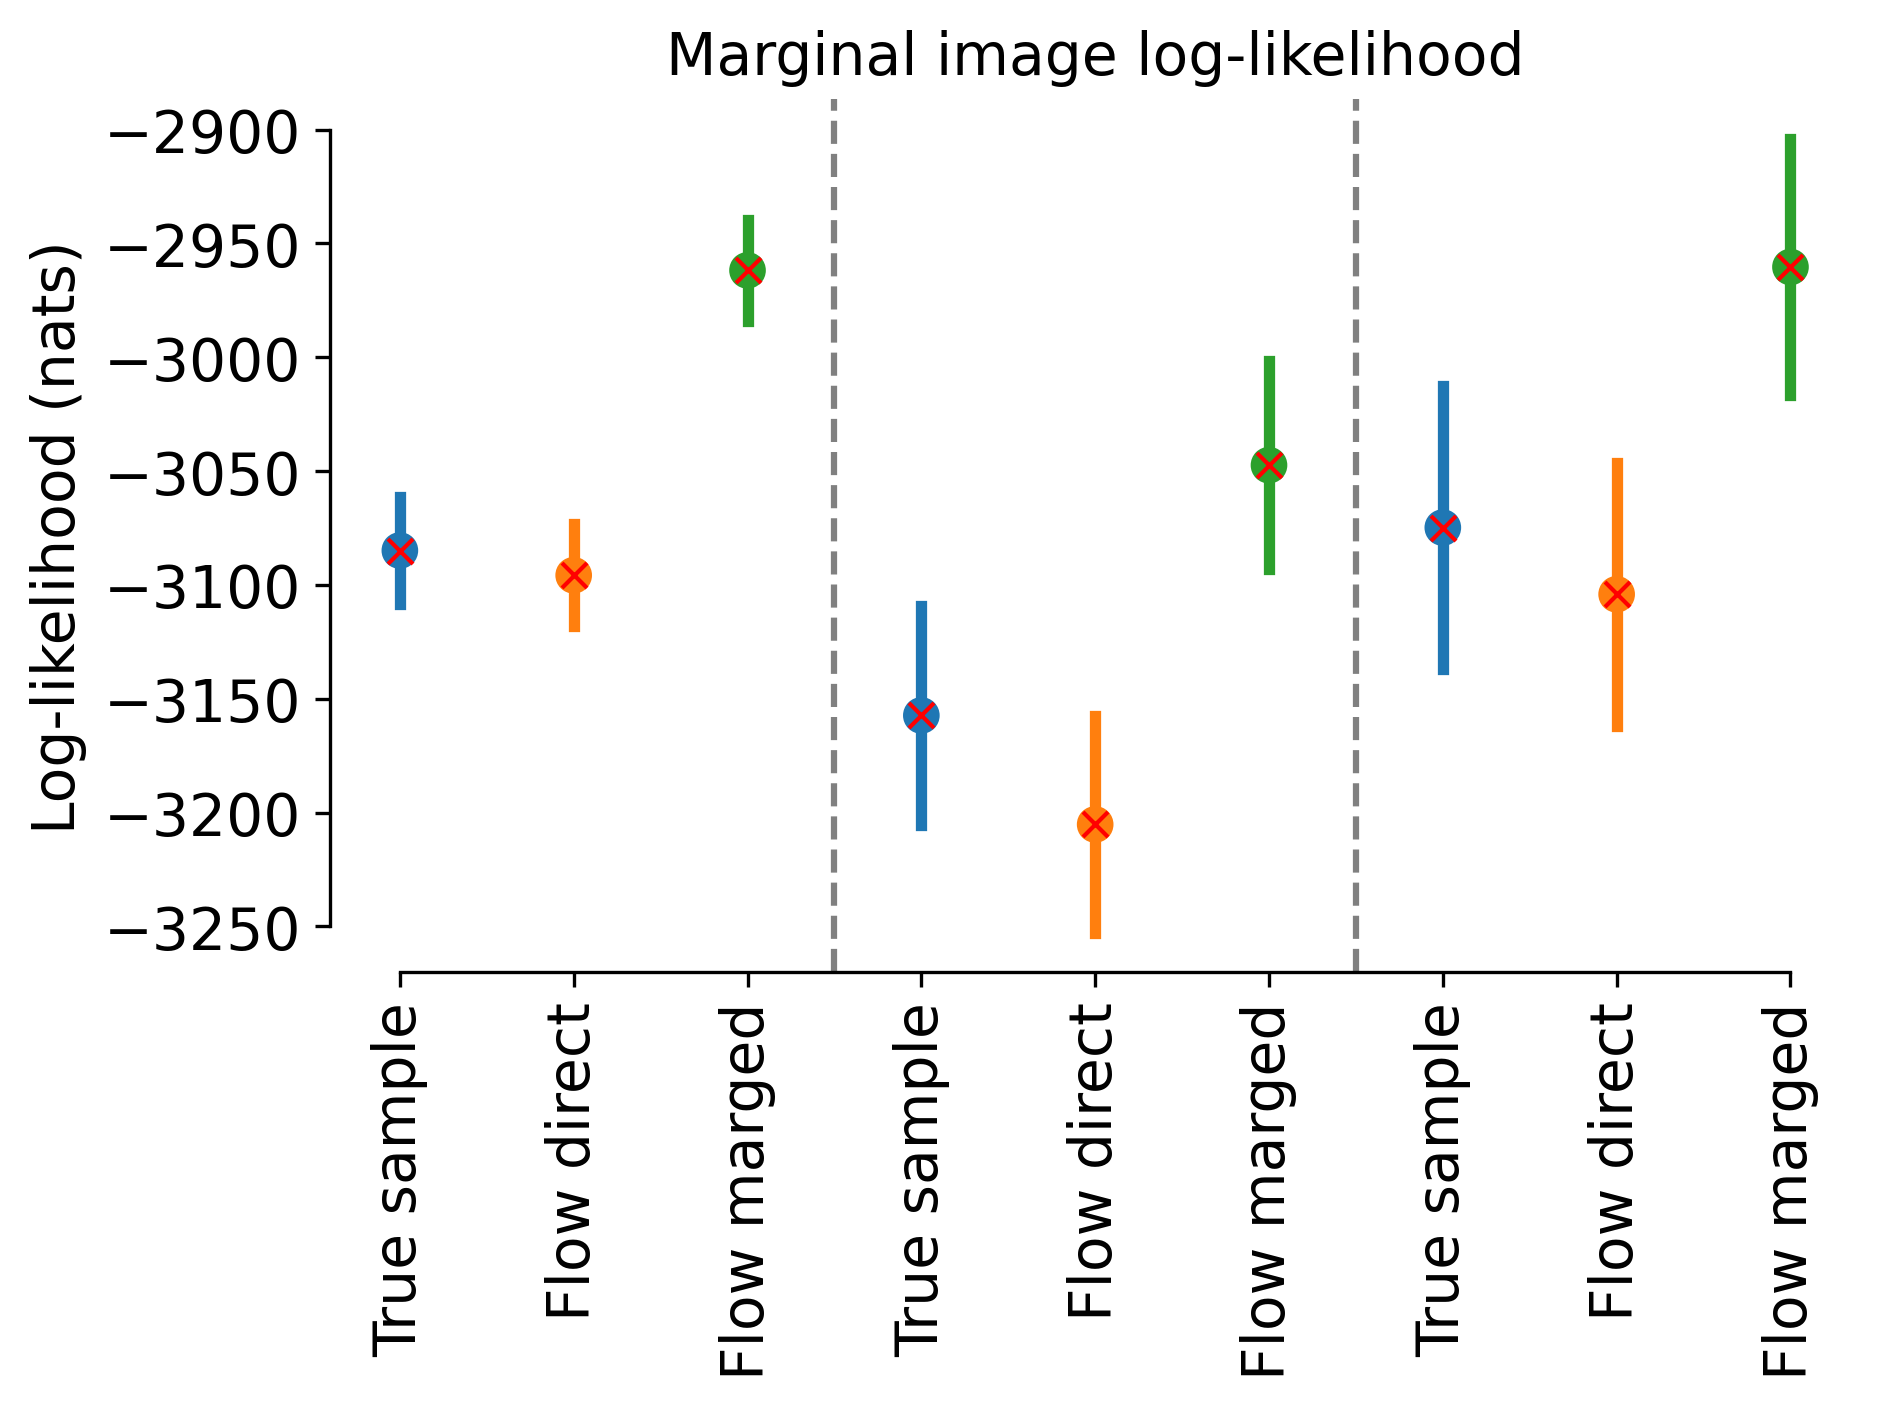

In [19]:
data = [
    true_logl_marg_train.detach(),
    logl_mc_marg_task_train.detach(),
    logl_mc_marg_adpt_train.detach(),
    true_logl_marg_val.detach(),
    logl_mc_marg_task_val.detach(),
    logl_mc_marg_adpt_val.detach(),
    true_logl_marg_test.detach(),
    logl_mc_marg_task_test.detach(),
    logl_mc_marg_adpt_test.detach(),
]
labels = [
    "True sample",
    "Flow direct",
    "Flow marged",
    "True sample",
    "Flow direct",
    "Flow marged",
    "True sample",
    "Flow direct",
    "Flow marged",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=3)
ax = sns.pointplot(data=data, ax=ax, palette=palette, errorbar="se")
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 3 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

In [22]:
data_dim = 0
device = torch.device("cuda:1")
reduction = "none"
uncertainty = "sem"
normalize = "none"
unit = "nats"

true_train_prior_lp, true_train_sem = compute_logl(
    model=true_prior,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_val_prior_lp, true_val_sem = compute_logl(
    model=true_prior,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_test_prior_lp, true_test_sem = compute_logl(
    model=true_prior,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [23]:
model_train_prior_lp, true_train_sem = compute_logl(
    model=prior_model,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
model_val_prior_lp, true_val_sem = compute_logl(
    model=prior_model,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
model_test_prior_lp, true_test_sem = compute_logl(
    model=prior_model,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)


In [26]:
adapted_model_train_prior_lp, true_train_sem = compute_logl(
    model=adapted_prior_model.prior,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
adapted_model_val_prior_lp, true_val_sem = compute_logl(
    model=adapted_prior_model.prior,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
adapted_model_test_prior_lp, true_test_sem = compute_logl(
    model=adapted_prior_model.prior,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

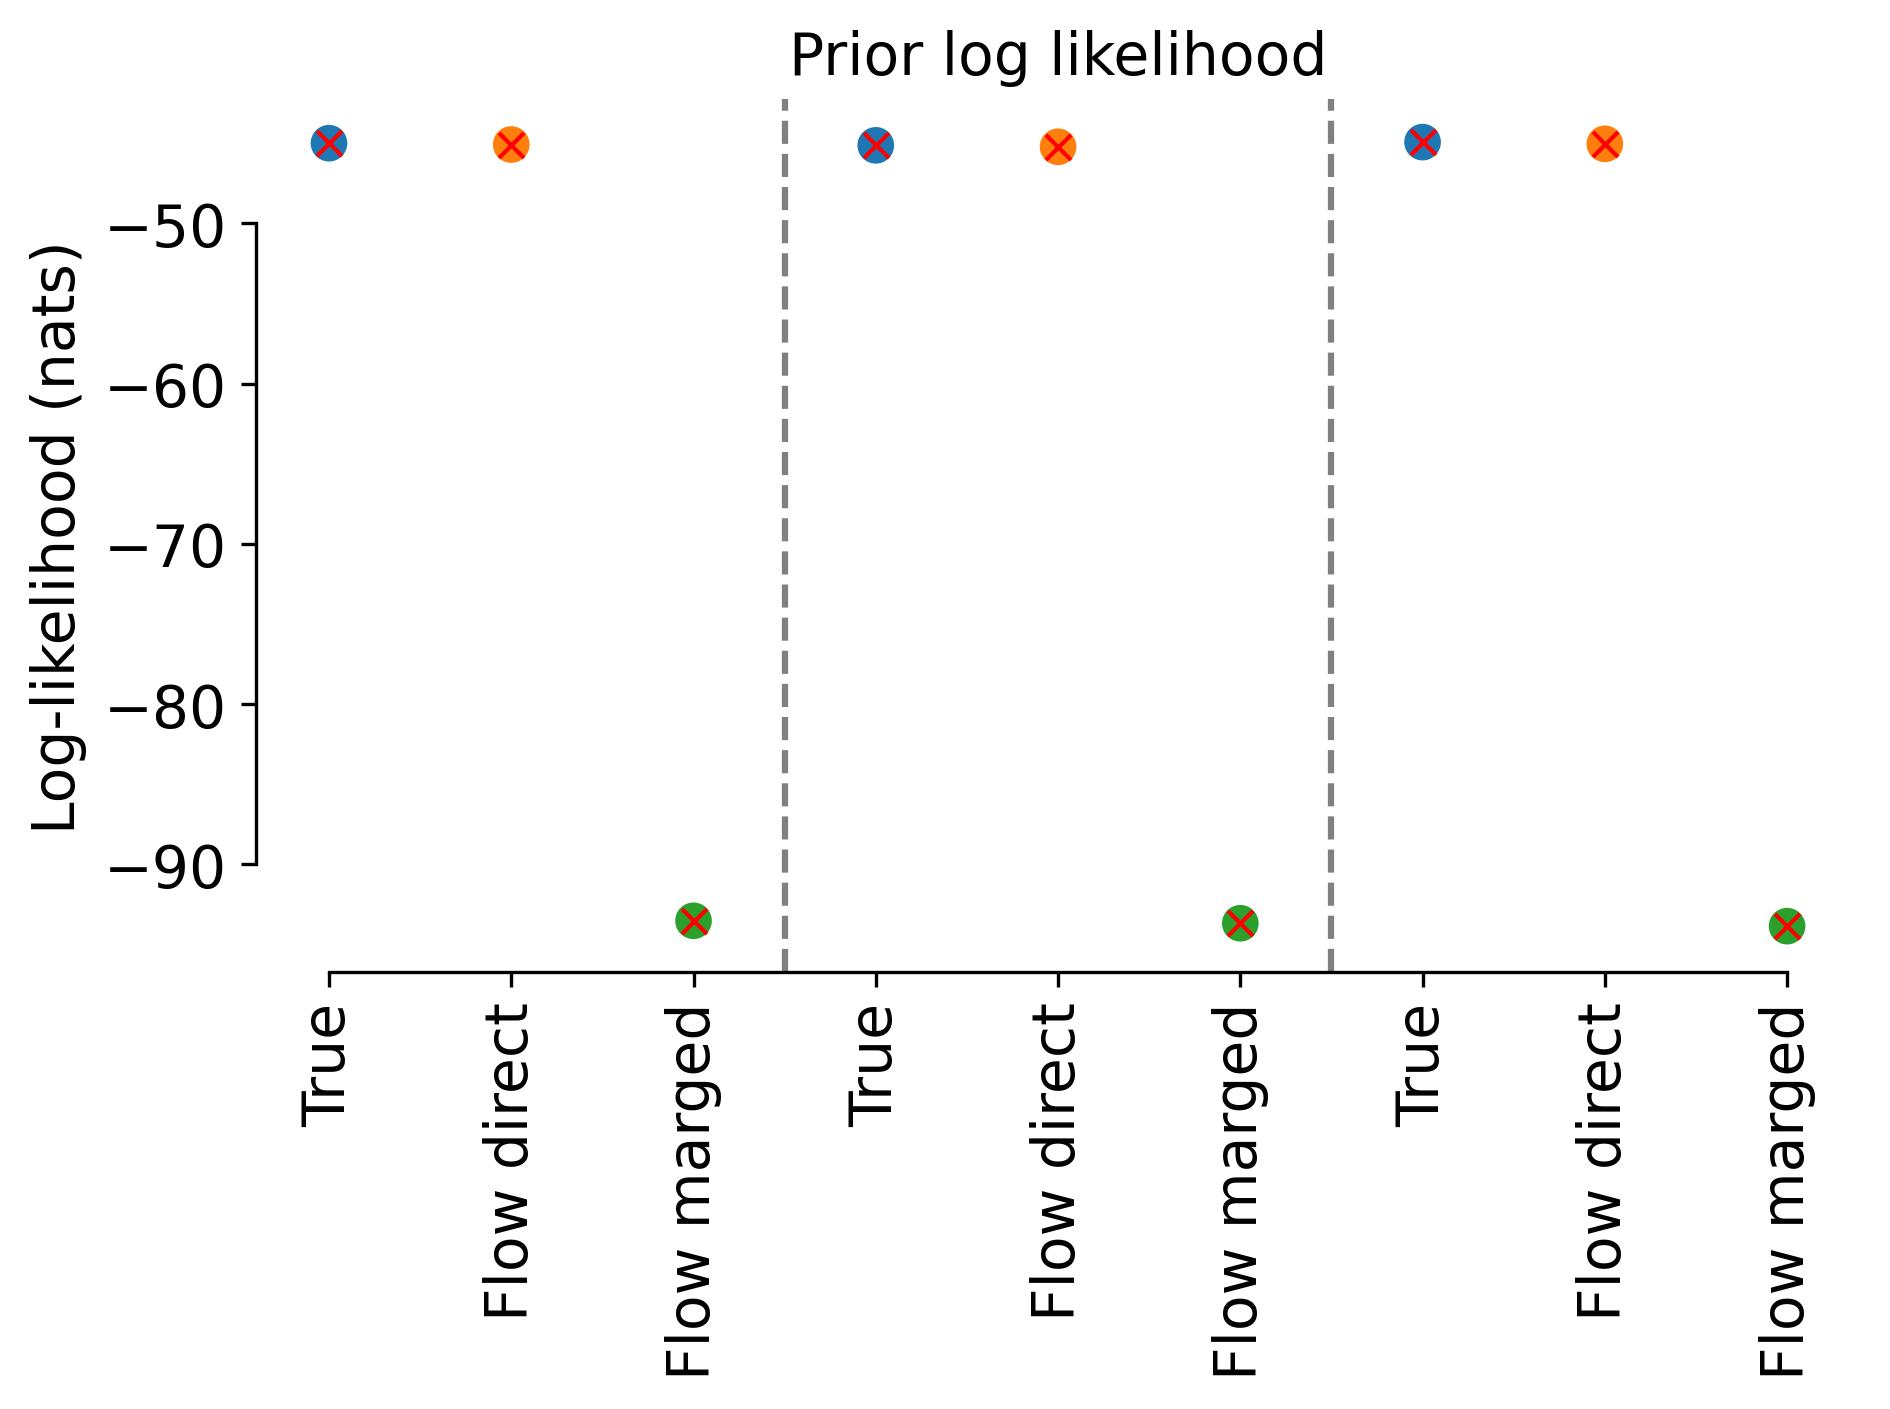

In [43]:
data = [
    true_train_prior_lp.detach().cpu(),
    model_train_prior_lp.detach().cpu(),
    adapted_model_train_prior_lp.detach().cpu(),
    true_val_prior_lp.detach().cpu(),
    model_val_prior_lp.detach().cpu(),
    adapted_model_val_prior_lp.detach().cpu(),
    true_test_prior_lp.detach().cpu(),
    model_test_prior_lp.detach().cpu(),
    adapted_model_test_prior_lp.detach().cpu(),
]
labels = [
    "True",
    "Flow direct",
    "Flow marged",
    "True",
    "Flow direct",
    "Flow marged",
    "True",
    "Flow direct",
    "Flow marged",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=3)
ax = sns.pointplot(data=data, ax=ax, palette=palette, errorbar="se")
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Prior log likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 3 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

In [57]:
from pathlib import Path

def visualize_marginal_flow(
    models,
    data_loader,
    device="cpu",
    density_support=(1e-3, 10),
    density_n_samples=1000,
    dims_to_plot=range(45),
    fig_dpi=300,
    linewidth=3,
    fontsize=10,
    plot_xlim=(0, 7),
    plot_ylim=(0, 1),
    data_color="darkorange",
    data_alpha=0.4,
    fig_save_dir=Path("/src/project/figures/learning/"),
    **catch_all,
):
    all_responses = []
    for batch in data_loader:
        responses, _ = batch
        all_responses.append(responses.to(device))
    all_responses = torch.cat(all_responses, dim=0)
    n_dims_to_plot = len(dims_to_plot)
    with torch.no_grad():
        n_dims_all = all_responses.shape[1]
        x = (
            torch.linspace(density_support[0], density_support[1], density_n_samples)
            .repeat(n_dims_all, 1)
            .T
        )
        fig, axs = plt.subplots(
            7,
            7,
            sharey=True,
            dpi=fig_dpi,
        )
        for idx, ax in zip(dims_to_plot, axs.ravel()):
            sns.histplot(
                all_responses[:, idx].detach().cpu(),
                ax=ax,
                stat="density",
                element="step",
                color=data_color,
                alpha=data_alpha,
                label="Data",
            )
        colors = sns.color_palette("tab10", n_colors=len(models))
        for model, color, label, linestyle in zip(models, colors, catch_all['labels'], catch_all["linestyles"]):
            flow_density = model.factorized_log_prob(x.to(device)).exp().cpu().numpy()
            print(flow_density.shape)
            for idx, ax in zip(dims_to_plot, axs.ravel()):
                ax.plot(
                    x[:, idx].detach().cpu(),
                    flow_density[:, idx],
                    linewidth=linewidth,
                    color=color,
                    label=label,
                    linestyle=linestyle,
                )
                ax.set_xlim(*plot_xlim)
                ax.set_ylim(*plot_ylim)
                ax.axis("off")
            # ax.tick_params(axis="both", which="both", labelsize=fontsize)
            # ax.set_ylabel("$p(x)$", fontsize=fontsize)
            # ax.set_xlabel("x", fontsize=fontsize)
            for ax in axs.ravel()[n_dims_to_plot:]:
                ax.axis("off")
        handles, labels = axs.flatten()[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower right", fontsize=fontsize)
        fig.savefig(
            fig_save_dir / catch_all["fig_name"],
            bbox_inches="tight",
            transparent=True,
        )
        # close the figure to avoid memory leak
        plt.close(fig)

In [58]:
visualize_marginal_flow(
    models=[true_prior, prior_model, adapted_prior_model.prior],
    data_loader=val_loader,
    device=device,
    density_support=(1e-3, 10),
    density_n_samples=1000,
    dims_to_plot=range(45),
    fig_dpi=300,
    linewidth=2,
    fontsize=10,
    plot_xlim=(0, 7),
    plot_ylim=(0, 1),
    data_color="lightpink",
    data_alpha=0.4,
    fig_save_dir=Path("/src/project/figures/learning/"),
    fig_name="marginal_flow.pdf",
    labels=["True", "Flow direct", "Flow marged"],
    linestyles=["-", "--", "dotted"],
)

(1000, 45)
(1000, 45)
(1000, 45)


In [48]:
visualize_marginal_flow(
    models=[true_prior, prior_model],
    data_loader=val_loader,
    device=device,
    density_support=(1e-3, 10),
    density_n_samples=1000,
    dims_to_plot=range(45),
    fig_dpi=300,
    linewidth=3,
    fontsize=10,
    plot_xlim=(0, 7),
    plot_ylim=(0, 1),
    data_color="pink",
    data_alpha=0.4,
    fig_save_dir=Path("/src/project/figures/learning/"),
    fig_name="twoflows.pdf",
    labels=["True", "Flow"],
)

(1000, 45)
(1000, 45)
